In [38]:
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

METRICS_DF_PATH = Path("../data/processed/metrics_df.csv")
metrics_df = pd.read_csv(METRICS_DF_PATH, index_col=0)

In [39]:
# look at the metrics df
metrics_df.head()

,CV Mean R²,CV Std,Test R² score,MAE,MSE,MAEP
Dummy,-0.00,0.00,-0.00,400.65,62377978.91,5.355070e+16
Linear Regression,-0.38,0.19,-0.37,1176.08,85409539.00,1.980106e+17
SVR,-0.00,0.00,0.00,174.41,62365019.06,1.795880e+15
Random Forest,-0.32,0.23,-0.08,211.02,67460975.87,2.229444e+15
XG Boost,-0.44,0.45,0.49,132.05,31965224.78,6.764440e+15


See the best model feature importances

In [42]:
# see best model feature importance
xg_boost_pipeline = joblib.load("../outputs/models/xg_boost.joblib")
# get the model
xg_boost_model = xg_boost_pipeline.named_steps["regressor"]
# get the preprocessor with the feature names
preprocessor = xg_boost_pipeline.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

# create importances dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xg_boost_model.feature_importances_
}).sort_values("importance", ascending=False)

# rename columns
importance_df = importance_df.rename(columns={"feature": "Feature", "importance": "Importance"})

Plot best features

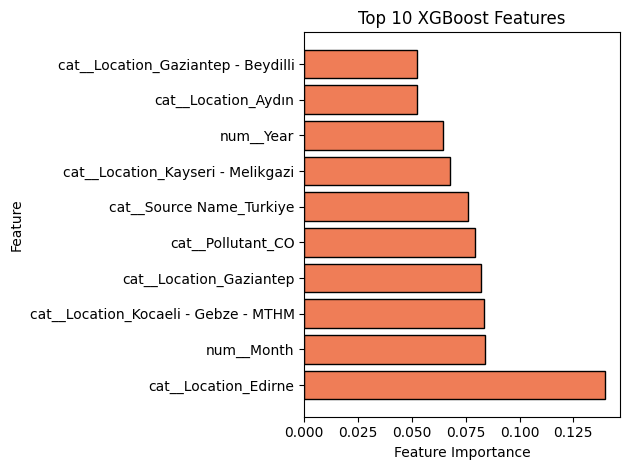

In [41]:
# look at the top features
top_features = importance_df.nlargest(10, "Importance")

plt.barh(top_features.Feature, top_features.Importance, edgecolor="black", color="#ef7d57")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Features")
plt.tight_layout()
plt.show()

## Machine Learning Results

I trained five regression models to predict pollution level (“Value” feature) based on numerical and categorical features. The models’ performance wasn’t great and may be explained by looking at a few statistics:
1.	The dummy regressor performed comparably to most models and outperformed linear regression, which is significant. By only using the median and the mode, the model achieved a better performance than linear regression and performed equally to SVR, in terms of 5-fold cross validation (CV) mean R2 score and test R2 score. 
This demonstrates that by just training a dummy model, a better performance can be attained by only using a simple strategy.
2.	The worst model was linear regression, which demonstrated my assumption that it doesn’t capture meaningful data patterns, due to simplistic assumptions. The negative R2 score (-0.37) and the highest mean absolute error (MAE) of 1176 confirm this.
3.	Most models showed similar CV and test performance. However, Random Forest and especially XGBoost exhibited substantial differences between cross-validation and test performance, suggesting that model performance is sensitive to the train/test split.
4.	The best models was XG Boost, which achieved the lowest MAE and MSE. Nonetheless, it fell short on R2 score metric, scoring 0.49 on the test set and -0.44 on the 5-fold CV mean R2 score, suggesting that the test split was easier. 
This was the case with random forest as well.
5.	Six of the ten most important features were location-related variables. This suggests that geographic information plays a major role in predicting pollution levels and may be more informative than many of the engineered numerical features.
The target variable is highly right-skewed and contains extreme values. This likely increases the difficulty of the prediction task and may partially explain the poor performance observed across most models.